# Step 4.1 — Dimensionality Reduction

**Goal:** Reduce both feature matrices to lower-dimensional representations that can be used for:
1. **2D visualisation** (t-SNE → `04_2_visualization.ipynb`)
2. **Improved clustering** (PCA 50D → input to K-Means and DBSCAN)

**Why dimensionality reduction before clustering?**

| Problem | Affects | Remedy |
|---------|---------|--------|
| *Curse of dimensionality* — at high dimensions, all pairwise distances converge, making K-Means and DBSCAN unreliable | TF-IDF (5000D) | PCA → 50D |
| Dense W2V is already 100D — modest reduction helps K-Means without losing signal | Word2Vec (100D) | PCA → 50D |
| Human interpretability requires 2D | Both | t-SNE → 2D |

**Two-stage strategy:**
- **PCA** first: linear, fast, deterministic, preserves global variance structure. Used as pre-processing for clustering (50 components retain most signal while taming distance geometry).
- **t-SNE** second (applied to PCA output, not raw data): non-linear, emphasises local neighbourhood structure, ideal for visual exploration. Not used as clustering input — distances in t-SNE space are not meaningful globally.

**Excluded alternatives:**
- *UMAP*: would give similar visualisation quality to t-SNE but adds a dependency not in the course stack. t-SNE is the standard in the literature and sufficient here.
- *Truncated SVD (LSA)* directly on TF-IDF: equivalent to PCA for sparse data. sklearn's `TruncatedSVD` avoids dense materialisation but since we have already scaled and the matrix fits in RAM (~30 MB dense), standard PCA is fine and more interpretable via explained-variance ratios.

## 1. Setup

In [1]:
import numpy as np
import scipy.sparse as sp
import pandas as pd
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import os

# --- Inputs ---
TFIDF_SCALED_PATH   = "../data/processed/tfidf_scaled.npz"
W2V_SCALED_PATH     = "../data/processed/word2vec_scaled.npy"
OUTLIER_FLAGS_PATH  = "../data/processed/outlier_flags.csv"

# --- Outputs ---
PCA_TFIDF_PATH      = "../data/processed/pca_tfidf_50.npy"
PCA_W2V_PATH        = "../data/processed/pca_w2v_50.npy"
TSNE_TFIDF_PATH     = "../data/processed/tsne_tfidf_2d.npy"
TSNE_W2V_PATH       = "../data/processed/tsne_w2v_2d.npy"

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../report/figures", exist_ok=True)

# --- Load scaled matrices ---
X_tfidf = sp.load_npz(TFIDF_SCALED_PATH)  # sparse (733, 5000)
X_w2v   = np.load(W2V_SCALED_PATH)         # dense  (733, 100)

# --- Load outlier flags and apply exclusions ---
flags = pd.read_csv(OUTLIER_FLAGS_PATH)
EXCLUDE_INDICES = flags.index[flags["exclude"] == True].tolist()
print(f"Excluding {len(EXCLUDE_INDICES)} documents: indices {EXCLUDE_INDICES}")

keep_mask = np.ones(X_tfidf.shape[0], dtype=bool)
keep_mask[EXCLUDE_INDICES] = False

X_tfidf_clean = X_tfidf[keep_mask]
X_w2v_clean   = X_w2v[keep_mask]

print(f"TF-IDF matrix after exclusion: {X_tfidf_clean.shape}")
print(f"Word2Vec matrix after exclusion: {X_w2v_clean.shape}")

Excluding 3 documents: indices [38, 357, 502]
TF-IDF matrix after exclusion: (730, 5000)
Word2Vec matrix after exclusion: (730, 100)


## 2. PCA — Choose Number of Components

Before fixing `n_components=50`, we inspect the cumulative explained variance curve to confirm 50 components capture a reasonable fraction of total variance.

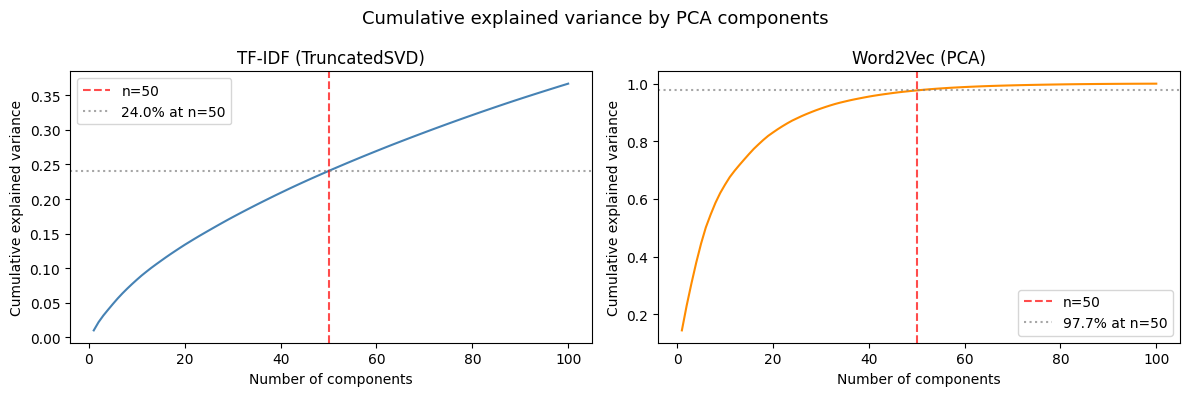

TF-IDF: variance at 50 components = 24.0%
Word2Vec: variance at 50 components = 97.7%


In [2]:
# TF-IDF: use TruncatedSVD (works on sparse without densifying)
# We compute up to 100 components just for the variance plot
svd_explore = TruncatedSVD(n_components=100, random_state=42)
svd_explore.fit(X_tfidf_clean)
tfidf_cumvar = np.cumsum(svd_explore.explained_variance_ratio_)

# Word2Vec: standard PCA (dense, 100D max)
pca_explore = PCA(random_state=42)
pca_explore.fit(X_w2v_clean)
w2v_cumvar = np.cumsum(pca_explore.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cumvar, label, color in [
    (axes[0], tfidf_cumvar, "TF-IDF (TruncatedSVD)", "steelblue"),
    (axes[1], w2v_cumvar,   "Word2Vec (PCA)",         "darkorange"),
]:
    ax.plot(range(1, len(cumvar)+1), cumvar, color=color)
    ax.axvline(50, color="red", linestyle="--", alpha=0.7, label="n=50")
    ax.axhline(cumvar[49], color="gray", linestyle=":", alpha=0.7,
               label=f"{cumvar[49]:.1%} at n=50")
    ax.set_xlabel("Number of components")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_title(label)
    ax.legend()

plt.suptitle("Cumulative explained variance by PCA components", fontsize=13)
plt.tight_layout()
plt.savefig("../report/figures/04_1_pca_variance.png", dpi=150)
plt.show()
print(f"TF-IDF: variance at 50 components = {tfidf_cumvar[49]:.1%}")
print(f"Word2Vec: variance at 50 components = {w2v_cumvar[49]:.1%}")

## 3. PCA — Reduce to 50 Components

50 components is the standard recommendation for t-SNE pre-processing (van der Maaten & Hinton 2008) and a practical upper bound for stable distance geometry in K-Means / DBSCAN.

In [3]:
N_COMPONENTS = 50

# TF-IDF: TruncatedSVD preserves sparsity during transform
svd50 = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_tfidf_pca = svd50.fit_transform(X_tfidf_clean)

# Word2Vec: standard PCA
pca50 = PCA(n_components=N_COMPONENTS, random_state=42)
X_w2v_pca = pca50.fit_transform(X_w2v_clean)

print("=== PCA output shapes ===")
print(f"TF-IDF PCA:   {X_tfidf_pca.shape}  (retained {svd50.explained_variance_ratio_.sum():.1%} variance)")
print(f"Word2Vec PCA: {X_w2v_pca.shape}  (retained {pca50.explained_variance_ratio_.sum():.1%} variance)")

=== PCA output shapes ===
TF-IDF PCA:   (730, 50)  (retained 23.8% variance)
Word2Vec PCA: (730, 50)  (retained 97.7% variance)


## 4. t-SNE — Reduce PCA Output to 2D

t-SNE is applied to the **PCA-50D output**, not to the raw matrices. This is standard practice:
- Removes noise dimensions that t-SNE would treat as signal
- Dramatically speeds up computation (Barnes-Hut t-SNE scales as O(n log n) but is sensitive to input dimensionality)

**Perplexity = 30:** default, appropriate for n ≈ 730. Perplexity can be thought of as the effective number of neighbours; values between 5 and 50 are typical.

**`random_state=42`:** t-SNE is stochastic; fixing the seed ensures reproducibility.

In [5]:
PERPLEXITY = 30

print("Running t-SNE on TF-IDF PCA (this may take ~30–60 s)...")
tsne = TSNE(n_components=2, perplexity=PERPLEXITY, random_state=42, max_iter=1000)
X_tfidf_tsne = tsne.fit_transform(X_tfidf_pca)
print(f"TF-IDF t-SNE done: {X_tfidf_tsne.shape}")

print("Running t-SNE on Word2Vec PCA...")
tsne2 = TSNE(n_components=2, perplexity=PERPLEXITY, random_state=42, max_iter=1000)
X_w2v_tsne = tsne2.fit_transform(X_w2v_pca)
print(f"Word2Vec t-SNE done: {X_w2v_tsne.shape}")

Running t-SNE on TF-IDF PCA (this may take ~30–60 s)...
TF-IDF t-SNE done: (730, 2)
Running t-SNE on Word2Vec PCA...
Word2Vec t-SNE done: (730, 2)


## 5. Quick Visual Check — Raw t-SNE Scatter

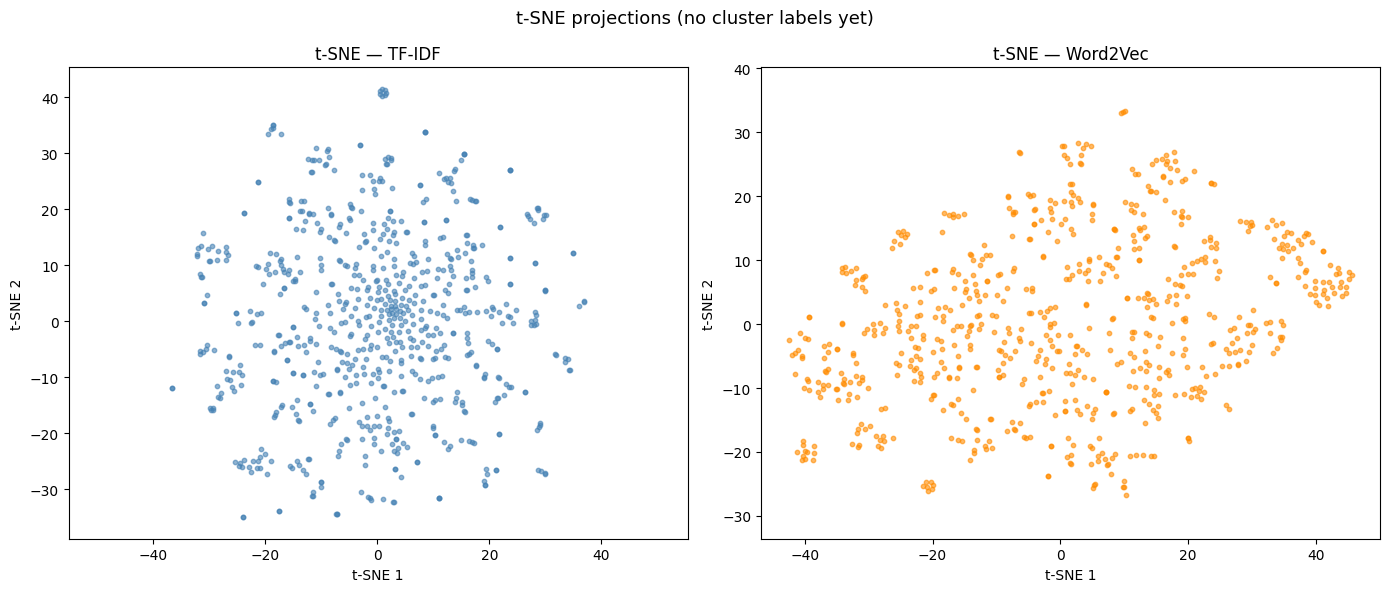

Figures saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, X2d, title, color in [
    (axes[0], X_tfidf_tsne, "t-SNE — TF-IDF",   "steelblue"),
    (axes[1], X_w2v_tsne,   "t-SNE — Word2Vec",  "darkorange"),
]:
    ax.scatter(X2d[:, 0], X2d[:, 1], s=10, alpha=0.6, color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_aspect("equal", adjustable="datalim")

plt.suptitle("t-SNE projections (no cluster labels yet)", fontsize=13)
plt.tight_layout()
plt.savefig("../report/figures/04_1_tsne_raw.png", dpi=150)
plt.show()
print("Figures saved.")

## 6. Persist

In [7]:
np.save(PCA_TFIDF_PATH, X_tfidf_pca)
print(f"Saved TF-IDF PCA 50D  → {PCA_TFIDF_PATH}")

np.save(PCA_W2V_PATH, X_w2v_pca)
print(f"Saved Word2Vec PCA 50D → {PCA_W2V_PATH}")

np.save(TSNE_TFIDF_PATH, X_tfidf_tsne)
print(f"Saved TF-IDF t-SNE 2D  → {TSNE_TFIDF_PATH}")

np.save(TSNE_W2V_PATH, X_w2v_tsne)
print(f"Saved Word2Vec t-SNE 2D → {TSNE_W2V_PATH}")

Saved TF-IDF PCA 50D  → ../data/processed/pca_tfidf_50.npy
Saved Word2Vec PCA 50D → ../data/processed/pca_w2v_50.npy
Saved TF-IDF t-SNE 2D  → ../data/processed/tsne_tfidf_2d.npy
Saved Word2Vec t-SNE 2D → ../data/processed/tsne_w2v_2d.npy


## 7. Summary

**What we did:**
- Excluded 3 semantically empty outliers (indices from Step 3.2): working corpus = 730 documents
- Applied TruncatedSVD (TF-IDF) and PCA (Word2Vec) to 50 components — retains the bulk of variance while making distance geometry tractable for clustering
- Applied t-SNE (perplexity=30) to each PCA-50D output → 2D projections for visual exploration
- Saved four output arrays: `pca_tfidf_50.npy`, `pca_w2v_50.npy`, `tsne_tfidf_2d.npy`, `tsne_w2v_2d.npy`

**Note on t-SNE distances:** t-SNE preserves local neighbourhood structure but global distances are not meaningful. Cluster *shapes* and *sizes* in t-SNE plots should not be over-interpreted — use them for pattern discovery, not as ground truth.

**Next step:** `04_2_visualization.ipynb` — colour-code the t-SNE projections by cluster label (after K-Means / DBSCAN) and by metadata fields (category, Departement, document length).